# Predicting Calories Burned from Apple Watch Outdoor Walk Data

Can Apple Watch workout data be used to predict how many calories are burned during an outdoor walk?

This project uses exported Apple Watch workout data to build a linear regression model that predicts **active calories burned** from features such as distance, elevation, average heart rate, and step cadence.

## 1. Import Libraries

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

## 2. Load the data

The dataset was exported from Apple Watch workout records as a CSV file. Each row represents a new workout session.

In [71]:
# Load the CSV Apple Watch workout data
df_workouts = pd.read_csv('workouts.csv')

# Preview the first few rows to understand the structure of the dataset
df_workouts.head()

,Workout Type,Start,End,Duration,Active Energy (kJ),Resting Energy (kJ),Intensity (kcal/hr·kg),Max. Heart Rate (count/min),Avg. Heart Rate (count/min),Distance (km),...,Step Cadence (spm),Swimming Stroke Count,Swim Cadence (spm),Lap Length (m),Swim Stroke Style,SWOLF Score,Water Salinity,Temperature (degC),Humidity (%),Location
0,Indoor Walk,30/04/2026 06:35,30/04/2026 06:59,00:23:07,538.376200,183.184139,5.254057,131.0,109.483214,2.039968,...,112.443579,0,0,0,NaN,0,NaN,7.750127,73,Indoor
1,Functional Strength Training,30/04/2026 06:04,30/04/2026 06:35,00:31:11,572.785416,241.291280,4.358219,151.0,99.263264,0.000000,...,8.047725,0,0,0,NaN,0,NaN,7.338853,74,Indoor
2,Outdoor Walk,29/04/2026 12:12,29/04/2026 13:09,00:56:27,1467.027552,438.588408,5.699458,146.0,107.675652,5.363411,...,109.898088,0,0,0,NaN,0,NaN,15.864819,44,Outdoor
3,Outdoor Walk,28/04/2026 12:05,28/04/2026 12:47,00:42:28,1018.672344,330.439654,5.363874,135.0,103.825171,4.051459,...,115.056386,0,0,0,NaN,0,NaN,11.998214,65,Outdoor
4,Functional Strength Training,28/04/2026 06:07,28/04/2026 06:59,00:51:47,1014.361793,400.187336,4.573515,157.0,107.747036,0.000000,...,11.948602,0,0,0,NaN,0,NaN,7.102712,82,Indoor


## 3. Initial Data Exploration

Before cleaning the data, I first checked the dataset shape, available workout types, column data types, missing values, and basic summary statistics.

In [72]:
# Check the number of rows and columns
print("Dataset shape:", df_workouts.shape)

# Check the workout types
print("\nWorkout types:")
print(df_workouts['Workout Type'].unique())

# Check column names, data types, and non-null counts
print("\nDataset information:")
df_workouts.info()

# Review summary statstics for numeric columns
print("\nSummary statistics:")
df_workouts.describe()

Dataset shape: (2421, 26)

Workout types:
['Indoor Walk' 'Functional Strength Training' 'Outdoor Walk'
 'Indoor Cycling' 'Traditional Strength Training' 'Indoor Run'
 'Cross Training' 'High Intensity Interval Training' 'Rowing'
 'Core Training' 'Outdoor Run' 'Hiking' 'Stairs']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2421 entries, 0 to 2420
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Workout Type                 2421 non-null   object 
 1   Start                        2421 non-null   object 
 2   End                          2421 non-null   object 
 3   Duration                     2421 non-null   object 
 4   Active Energy (kJ)           2421 non-null   float64
 5   Resting Energy (kJ)          2421 non-null   float64
 6   Intensity (kcal/hr·kg)       2421 non-null   float64
 7   Max. Heart Rate (count/min)  2421 non-null   float64
 8   Avg. Hea

,Active Energy (kJ),Resting Energy (kJ),Intensity (kcal/hr·kg),Max. Heart Rate (count/min),Avg. Heart Rate (count/min),Distance (km),Max. Speed (km/hr),Avg. Speed (km/hr),Flights Climbed,Elevation Ascended (m),...,Step Count,Step Cadence (spm),Swimming Stroke Count,Swim Cadence (spm),Lap Length (m),Swim Stroke Style,SWOLF Score,Water Salinity,Temperature (degC),Humidity (%)
count,2421.000000,2421.000000,2421.000000,2421.000000,2421.000000,2421.000000,2421.0,2421.0,2421.0,2421.000000,...,2421.000000,2421.000000,2421.0,2421.0,2421.0,0.0,2421.0,0.0,2421.000000,2421.000000
mean,870.724069,151.913252,5.048640,131.516977,105.401600,1.291205,0.0,0.0,0.0,9.722053,...,1749.316027,53.557261,0.0,0.0,0.0,NaN,0.0,NaN,8.660094,68.760017
std,671.620929,155.290673,2.573381,32.744783,26.771196,1.887684,0.0,0.0,0.0,21.357019,...,2106.166423,42.426635,0.0,0.0,0.0,NaN,0.0,NaN,6.576342,30.120993
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,NaN,0.0,NaN,-6.887987,0.000000
25%,336.118530,5.658184,3.613594,102.000000,82.317684,0.000000,0.0,0.0,0.0,0.000000,...,479.266821,11.552795,0.0,0.0,0.0,NaN,0.0,NaN,3.000000,61.000000
50%,704.066784,133.963585,4.684323,131.000000,102.345729,0.895233,0.0,0.0,0.0,0.000000,...,1261.000000,53.298020,0.0,0.0,0.0,NaN,0.0,NaN,8.534189,81.000000
75%,1217.995872,249.903903,6.836289,160.000000,125.075592,1.708265,0.0,0.0,0.0,9.270000,...,2052.023946,85.910369,0.0,0.0,0.0,NaN,0.0,NaN,13.070454,89.000000
max,6199.447867,1852.894896,11.237240,204.000000,192.331310,19.138312,0.0,0.0,0.0,463.890000,...,25193.143040,170.795698,0.0,0.0,0.0,NaN,0.0,NaN,31.550000,100.000000


## 4. Filter to Outdoor Walks

Only outdoor walking workouts were included because the aim of this project is to model calorie burn for that one activity type.

In [73]:
# Keep only Outdoor Walk workouts
df_walks = df_workouts[df_workouts['Workout Type'] == 'Outdoor Walk'].copy()

# Drop Location because it is not needed for this model as it only states 'Indoor' or 'Outdoor' and we are only using Outdoor Walks
df_walks = df_walks.drop(columns=['Location'])

print("Outdoor walk dataset shape:", df_walks.shape)
df_walks.head()

Outdoor walk dataset shape: (1094, 25)


,Workout Type,Start,End,Duration,Active Energy (kJ),Resting Energy (kJ),Intensity (kcal/hr·kg),Max. Heart Rate (count/min),Avg. Heart Rate (count/min),Distance (km),...,Step Count,Step Cadence (spm),Swimming Stroke Count,Swim Cadence (spm),Lap Length (m),Swim Stroke Style,SWOLF Score,Water Salinity,Temperature (degC),Humidity (%)
2,Outdoor Walk,29/04/2026 12:12,29/04/2026 13:09,00:56:27,1467.027552,438.588408,5.699458,146.0,107.675652,5.363411,...,6205.000000,109.898088,0,0,0,NaN,0,NaN,15.864819,44
3,Outdoor Walk,28/04/2026 12:05,28/04/2026 12:47,00:42:28,1018.672344,330.439654,5.363874,135.0,103.825171,4.051459,...,4886.465090,115.056386,0,0,0,NaN,0,NaN,11.998214,65
5,Outdoor Walk,27/04/2026 12:07,27/04/2026 13:02,00:54:22,1351.749779,423.246424,5.504569,139.0,102.395144,5.115351,...,5554.576184,102.164911,0,0,0,NaN,0,NaN,16.504419,54
8,Outdoor Walk,24/04/2026 12:11,24/04/2026 13:14,01:02:41,1485.586091,484.928948,5.311714,136.0,98.458653,5.809985,...,6334.000000,101.034027,0,0,0,NaN,0,NaN,15.450564,45
10,Outdoor Walk,23/04/2026 12:13,23/04/2026 13:22,01:09:07,1631.508988,538.266790,5.249767,151.0,102.941766,5.775359,...,6372.000000,92.177643,0,0,0,NaN,0,NaN,14.351376,49


## 5. Clean and Transform the Data

Several columns needed to be converted before they could be used in a machine learning model:

In [74]:
# Convert Start to datetime and keep only the date
df_walks['Start'] = pd.to_datetime(df_walks['Start'], dayfirst=True).dt.normalize()
df_walks.rename(columns={'Start': 'Date'}, inplace=True)

# Drop End because it is not needed
df_walks.drop(columns=['End'], inplace=True)

# Convert duration into minutes 
df_walks['Duration'] = pd.to_timedelta(df_walks['Duration']).dt.total_seconds() / 60

# Convert energy from kJ to kcal
df_walks['Active Energy (kcal)'] = df_walks['Active Energy (kJ)'] / 4.184
df_walks['Resting Energy (kcal)'] = df_walks['Resting Energy (kJ)'] / 4.184

# Drop original kJ columns after conversion
df_walks.drop(columns=['Active Energy (kJ)', 'Resting Energy (kJ)'], inplace=True)

# Preview cleaned columns
df_walks.head()

,Workout Type,Date,Duration,Intensity (kcal/hr·kg),Max. Heart Rate (count/min),Avg. Heart Rate (count/min),Distance (km),Max. Speed (km/hr),Avg. Speed (km/hr),Flights Climbed,...,Swimming Stroke Count,Swim Cadence (spm),Lap Length (m),Swim Stroke Style,SWOLF Score,Water Salinity,Temperature (degC),Humidity (%),Active Energy (kcal),Resting Energy (kcal)
2,Outdoor Walk,2026-04-29,56.450000,5.699458,146.0,107.675652,5.363411,0,0,0,...,0,0,0,NaN,0,NaN,15.864819,44,350.628000,104.825145
3,Outdoor Walk,2026-04-28,42.466667,5.363874,135.0,103.825171,4.051459,0,0,0,...,0,0,0,NaN,0,NaN,11.998214,65,243.468533,78.976973
5,Outdoor Walk,2026-04-27,54.366667,5.504569,139.0,102.395144,5.115351,0,0,0,...,0,0,0,NaN,0,NaN,16.504419,54,323.075951,101.158323
8,Outdoor Walk,2026-04-24,62.683333,5.311714,136.0,98.458653,5.809985,0,0,0,...,0,0,0,NaN,0,NaN,15.450564,45,355.063597,115.900800
10,Outdoor Walk,2026-04-23,69.116667,5.249767,151.0,102.941766,5.775359,0,0,0,...,0,0,0,NaN,0,NaN,14.351376,49,389.940007,128.648850


## 6. Data Quality Checks

The data was checked for duplicates, missing values and zero values.
This step is important because wearable data can include short accidental recordings, missing sensor readings, or incomplete activity records.

In [75]:
# Check for duplicate rows
print("Duplicate rows:", df_walks.duplicated().sum())

# Check missing values by column
print("\nMissing values:")
print(df_walks.isnull().sum())

# Check zero values by column
print("\nZero values:")
print((df_walks == 0).sum())

# Check summary statistics after cleaning
df_walks.describe()

Duplicate rows: 0

Missing values:
Workout Type                      0
Date                              0
Duration                          0
Intensity (kcal/hr·kg)            0
Max. Heart Rate (count/min)       0
Avg. Heart Rate (count/min)       0
Distance (km)                     0
Max. Speed (km/hr)                0
Avg. Speed (km/hr)                0
Flights Climbed                   0
Elevation Ascended (m)            0
Elevation Descended (m)           0
Step Count                        0
Step Cadence (spm)                0
Swimming Stroke Count             0
Swim Cadence (spm)                0
Lap Length (m)                    0
Swim Stroke Style              1094
SWOLF Score                       0
Water Salinity                 1094
Temperature (degC)                0
Humidity (%)                      0
Active Energy (kcal)              0
Resting Energy (kcal)             0
dtype: int64

Zero values:
Workout Type                      0
Date                              0
Du

,Date,Duration,Intensity (kcal/hr·kg),Max. Heart Rate (count/min),Avg. Heart Rate (count/min),Distance (km),Max. Speed (km/hr),Avg. Speed (km/hr),Flights Climbed,Elevation Ascended (m),...,Swimming Stroke Count,Swim Cadence (spm),Lap Length (m),Swim Stroke Style,SWOLF Score,Water Salinity,Temperature (degC),Humidity (%),Active Energy (kcal),Resting Energy (kcal)
count,1094,1094.000000,1094.000000,1094.000000,1094.000000,1094.000000,1094.0,1094.0,1094.0,1094.000000,...,1094.0,1094.0,1094.0,0.0,1094.0,0.0,1094.000000,1094.000000,1094.000000,1094.000000
mean,2022-07-08 03:16:07.458866432,28.170795,4.265450,108.419561,88.469545,1.886911,0.0,0.0,0.0,17.637404,...,0.0,0.0,0.0,NaN,0.0,NaN,10.583269,69.597806,120.312460,32.737126
min,2020-04-15 00:00:00,0.116667,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,NaN,0.0,NaN,-3.000000,0.000000,0.000000,0.000000
25%,2021-03-04 06:00:00,20.862500,3.521599,92.000000,76.173659,1.091267,0.0,0.0,0.0,5.390000,...,0.0,0.0,0.0,NaN,0.0,NaN,6.000000,59.000000,70.978905,1.799639
50%,2021-08-22 12:00:00,25.166667,3.989704,106.000000,84.491228,1.322641,0.0,0.0,0.0,8.445000,...,0.0,0.0,0.0,NaN,0.0,NaN,10.604623,77.000000,89.330589,31.779271
75%,2023-07-21 06:00:00,32.020833,5.051221,122.000000,101.566066,2.263907,0.0,0.0,0.0,16.587500,...,0.0,0.0,0.0,NaN,0.0,NaN,15.000000,87.000000,135.095153,45.582712
max,2026-04-29 00:00:00,262.833333,8.514424,192.000000,172.459312,19.138312,0.0,0.0,0.0,463.890000,...,0.0,0.0,0.0,NaN,0.0,NaN,31.550000,99.000000,1481.703601,442.852509
std,NaN,16.832362,0.996448,20.600287,15.696836,1.616172,0.0,0.0,0.0,26.459152,...,0.0,0.0,0.0,NaN,0.0,NaN,6.750652,24.934517,105.197022,34.525582


In [76]:
# Remove workouts where active calories are zero
df_walks = df_walks[df_walks['Active Energy (kcal)'] > 0]

# Remove columns where every value is zero or every value is missing,these columns do not provide useful information to the model
df_walks = df_walks.loc[:, (df_walks != 0).any(axis=0)]
df_walks = df_walks.dropna(axis=1, how='all')

print("Shape after removing empty columns and zero-calorie walks:", df_walks.shape)

Shape after removing empty columns and zero-calorie walks: (1092, 14)


In [77]:
# Remove rows where key workout measurements are zero
columns = [
    'Resting Energy (kcal)',
    'Intensity (kcal/hr·kg)',
    'Max. Heart Rate (count/min)',
    'Avg. Heart Rate (count/min)',
    'Distance (km)',
    'Step Count',
    'Step Cadence (spm)'
]

for col in columns:
    df_walks = df_walks[df_walks[col] > 0]

print("Shape after removing invalid values:", df_walks.shape)
print("Remaining zero values:")
print((df_walks == 0).sum())

Shape after removing invalid values: (1084, 14)
Remaining zero values:
Workout Type                     0
Date                             0
Duration                         0
Intensity (kcal/hr·kg)           0
Max. Heart Rate (count/min)      0
Avg. Heart Rate (count/min)      0
Distance (km)                    0
Elevation Ascended (m)         100
Step Count                       0
Step Cadence (spm)               0
Temperature (degC)              78
Humidity (%)                    78
Active Energy (kcal)             0
Resting Energy (kcal)            0
dtype: int64


### Humidity & Temperature Values

Some rows had zero values for both temperature and humidity. These may have been caused by missing sensor or connectivity data rather than genuine weather conditions.

In the final model, temperature and humidity were not selected as important features, so the modelling result is not dependent on these fields.

In [78]:
# Inspect rows where both temperature and humidity are zero
weather_zero_rows = df_walks[
    (df_walks['Temperature (degC)'] == 0) &
    (df_walks['Humidity (%)'] == 0)
]

weather_zero_rows

,Workout Type,Date,Duration,Intensity (kcal/hr·kg),Max. Heart Rate (count/min),Avg. Heart Rate (count/min),Distance (km),Elevation Ascended (m),Step Count,Step Cadence (spm),Temperature (degC),Humidity (%),Active Energy (kcal),Resting Energy (kcal)
54,Outdoor Walk,2026-03-31,34.916667,6.143492,127.0,116.144764,3.677973,40.11,3153.384163,90.275456,0.0,0,238.359751,64.369759
55,Outdoor Walk,2026-03-31,38.116667,5.568955,115.0,101.612429,4.021334,18.58,3567.267727,93.576314,0.0,0,229.441355,71.677239
57,Outdoor Walk,2026-03-30,55.933333,6.210335,143.0,108.369443,5.810612,92.01,6031.784949,107.829151,0.0,0,388.177033,103.028662
68,Outdoor Walk,2026-03-23,30.900000,5.807927,108.0,94.291667,3.161222,39.69,3016.000000,97.601821,0.0,0,196.265556,56.996825
72,Outdoor Walk,2026-03-20,45.016667,5.733110,130.0,110.519258,4.494460,53.63,4713.000000,104.675394,0.0,0,282.021716,84.387524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011,Outdoor Walk,2021-02-21,38.450000,5.579394,155.0,111.995664,3.666839,39.93,4525.000000,117.639500,0.0,0,218.130274,57.359181
2018,Outdoor Walk,2021-02-14,39.233333,4.928466,117.0,90.016449,2.915910,48.12,4119.377377,104.956811,0.0,0,189.151000,69.031779
2101,Outdoor Walk,2021-01-03,45.383333,4.682575,117.0,94.316140,2.923026,71.56,4393.000000,96.790175,0.0,0,204.370910,70.532244
2131,Outdoor Walk,2020-12-08,12.966667,3.739460,87.0,74.754438,0.544092,0.00,801.405306,61.735679,0.0,0,43.057000,22.390274


In [79]:
# Optional cleaning choice:
# Remove rows where both temperature and humidity are zero.
# If these columns are later dropped from the model, keeping these rows may also be ok.

# df_walks = df_walks[~(
#     (df_walks['Temperature (degC)'] == 0) &
#     (df_walks['Humidity (%)'] == 0)
# )]

# print("Final cleaned dataset shape:", df_walks.shape)
# df_walks.info()

## 7. Explore Distributions and Outliers

The histograms show how each numerical variable is distributed. The boxplots help identify potential outliers.

The outliers were kept because they appear to represent genuine variation in walking sessions rather than data entry errors.

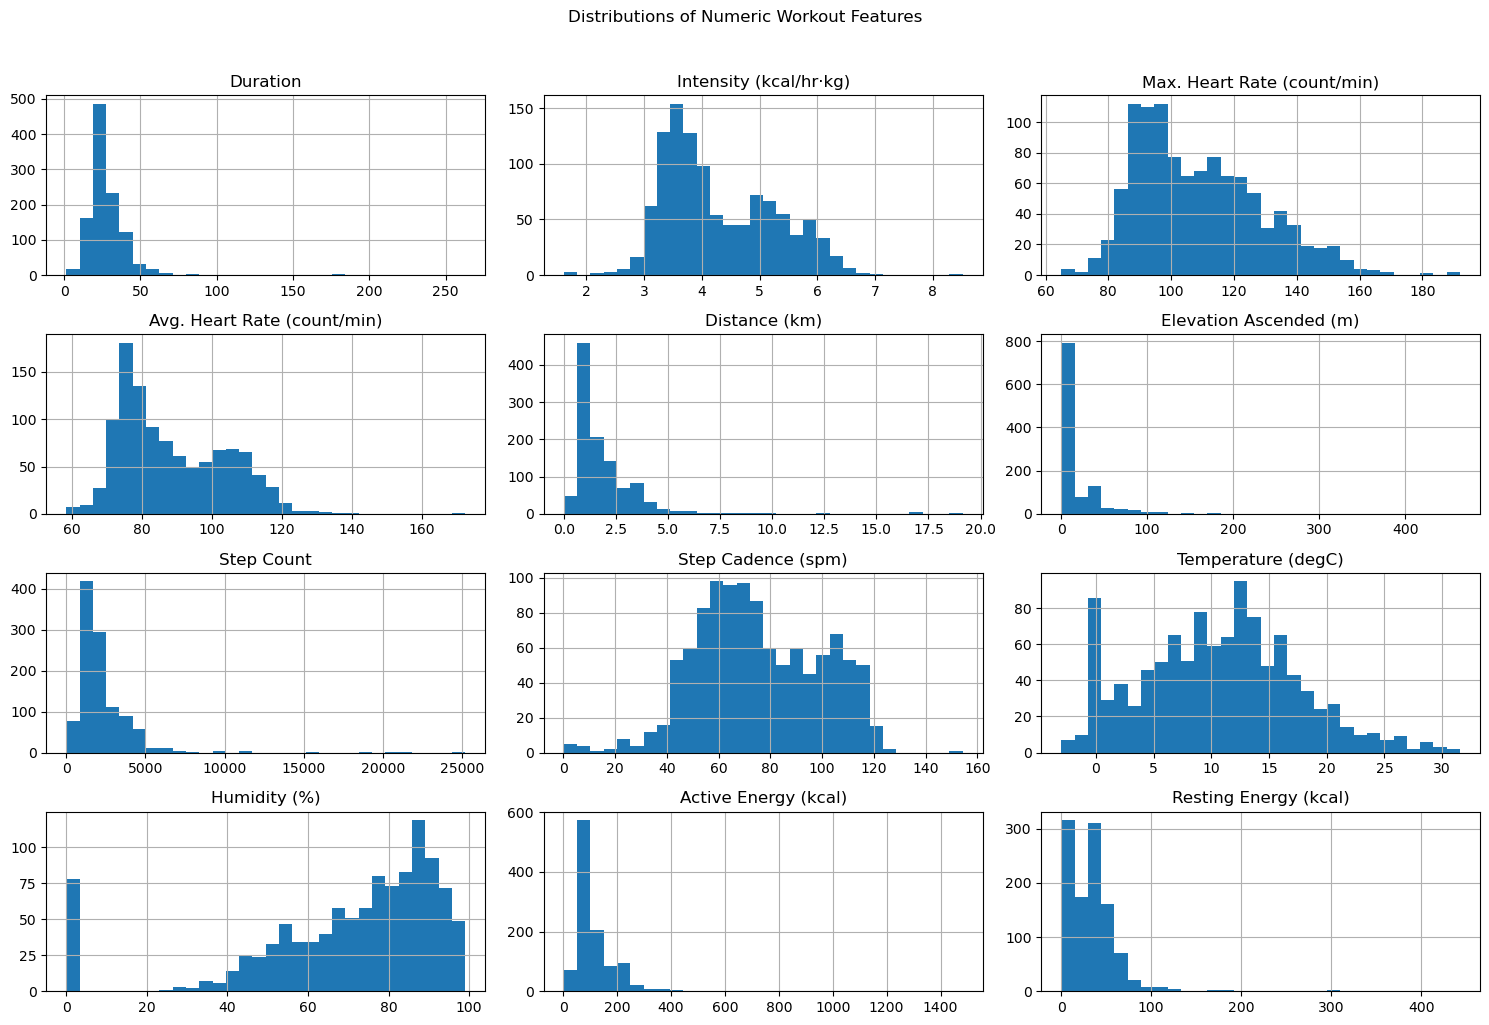

In [80]:
numeric_cols = df_walks.select_dtypes(include='number').columns

# Plot histograms
df_walks[numeric_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle('Distributions of Numeric Workout Features', y=1.02)
plt.tight_layout()
plt.show()

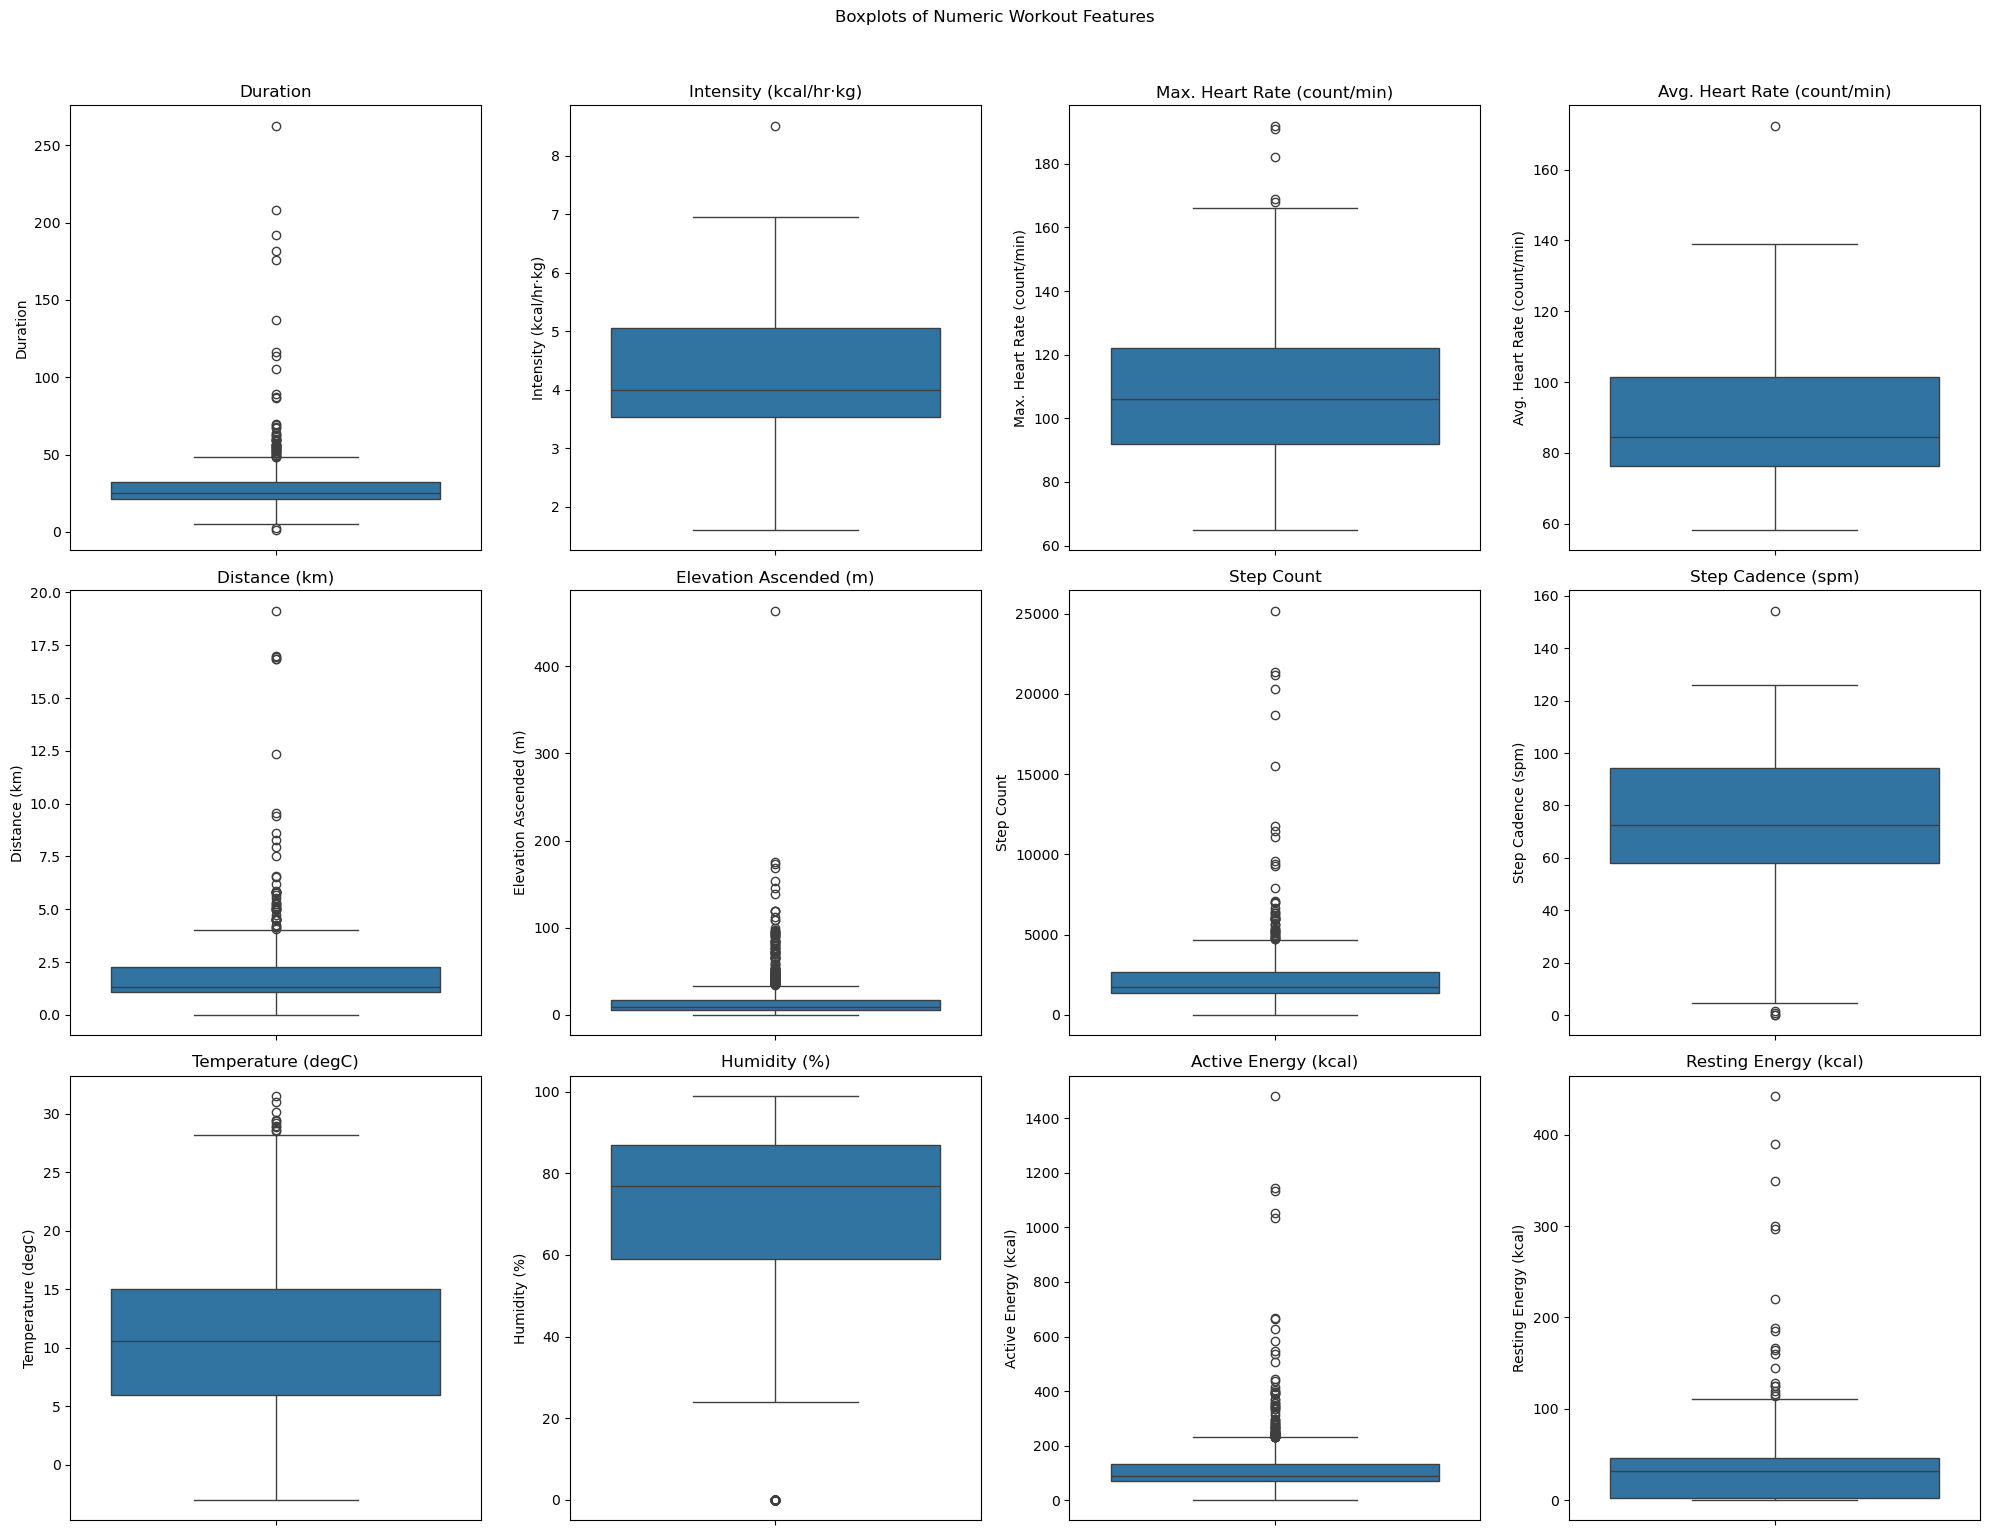

In [81]:
# Create boxplots to check for outliers
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_walks, y=col, ax=axes[i])
    axes[i].set_title(f'{col}')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of Numeric Workout Features', y=1.02)
plt.tight_layout()
plt.show()

## 8. Explore Relationships with Calories Burned

Scatterplots were used to check whether each feature had a relationship with active calories burned. This helped decide whether linear regression was suitable.

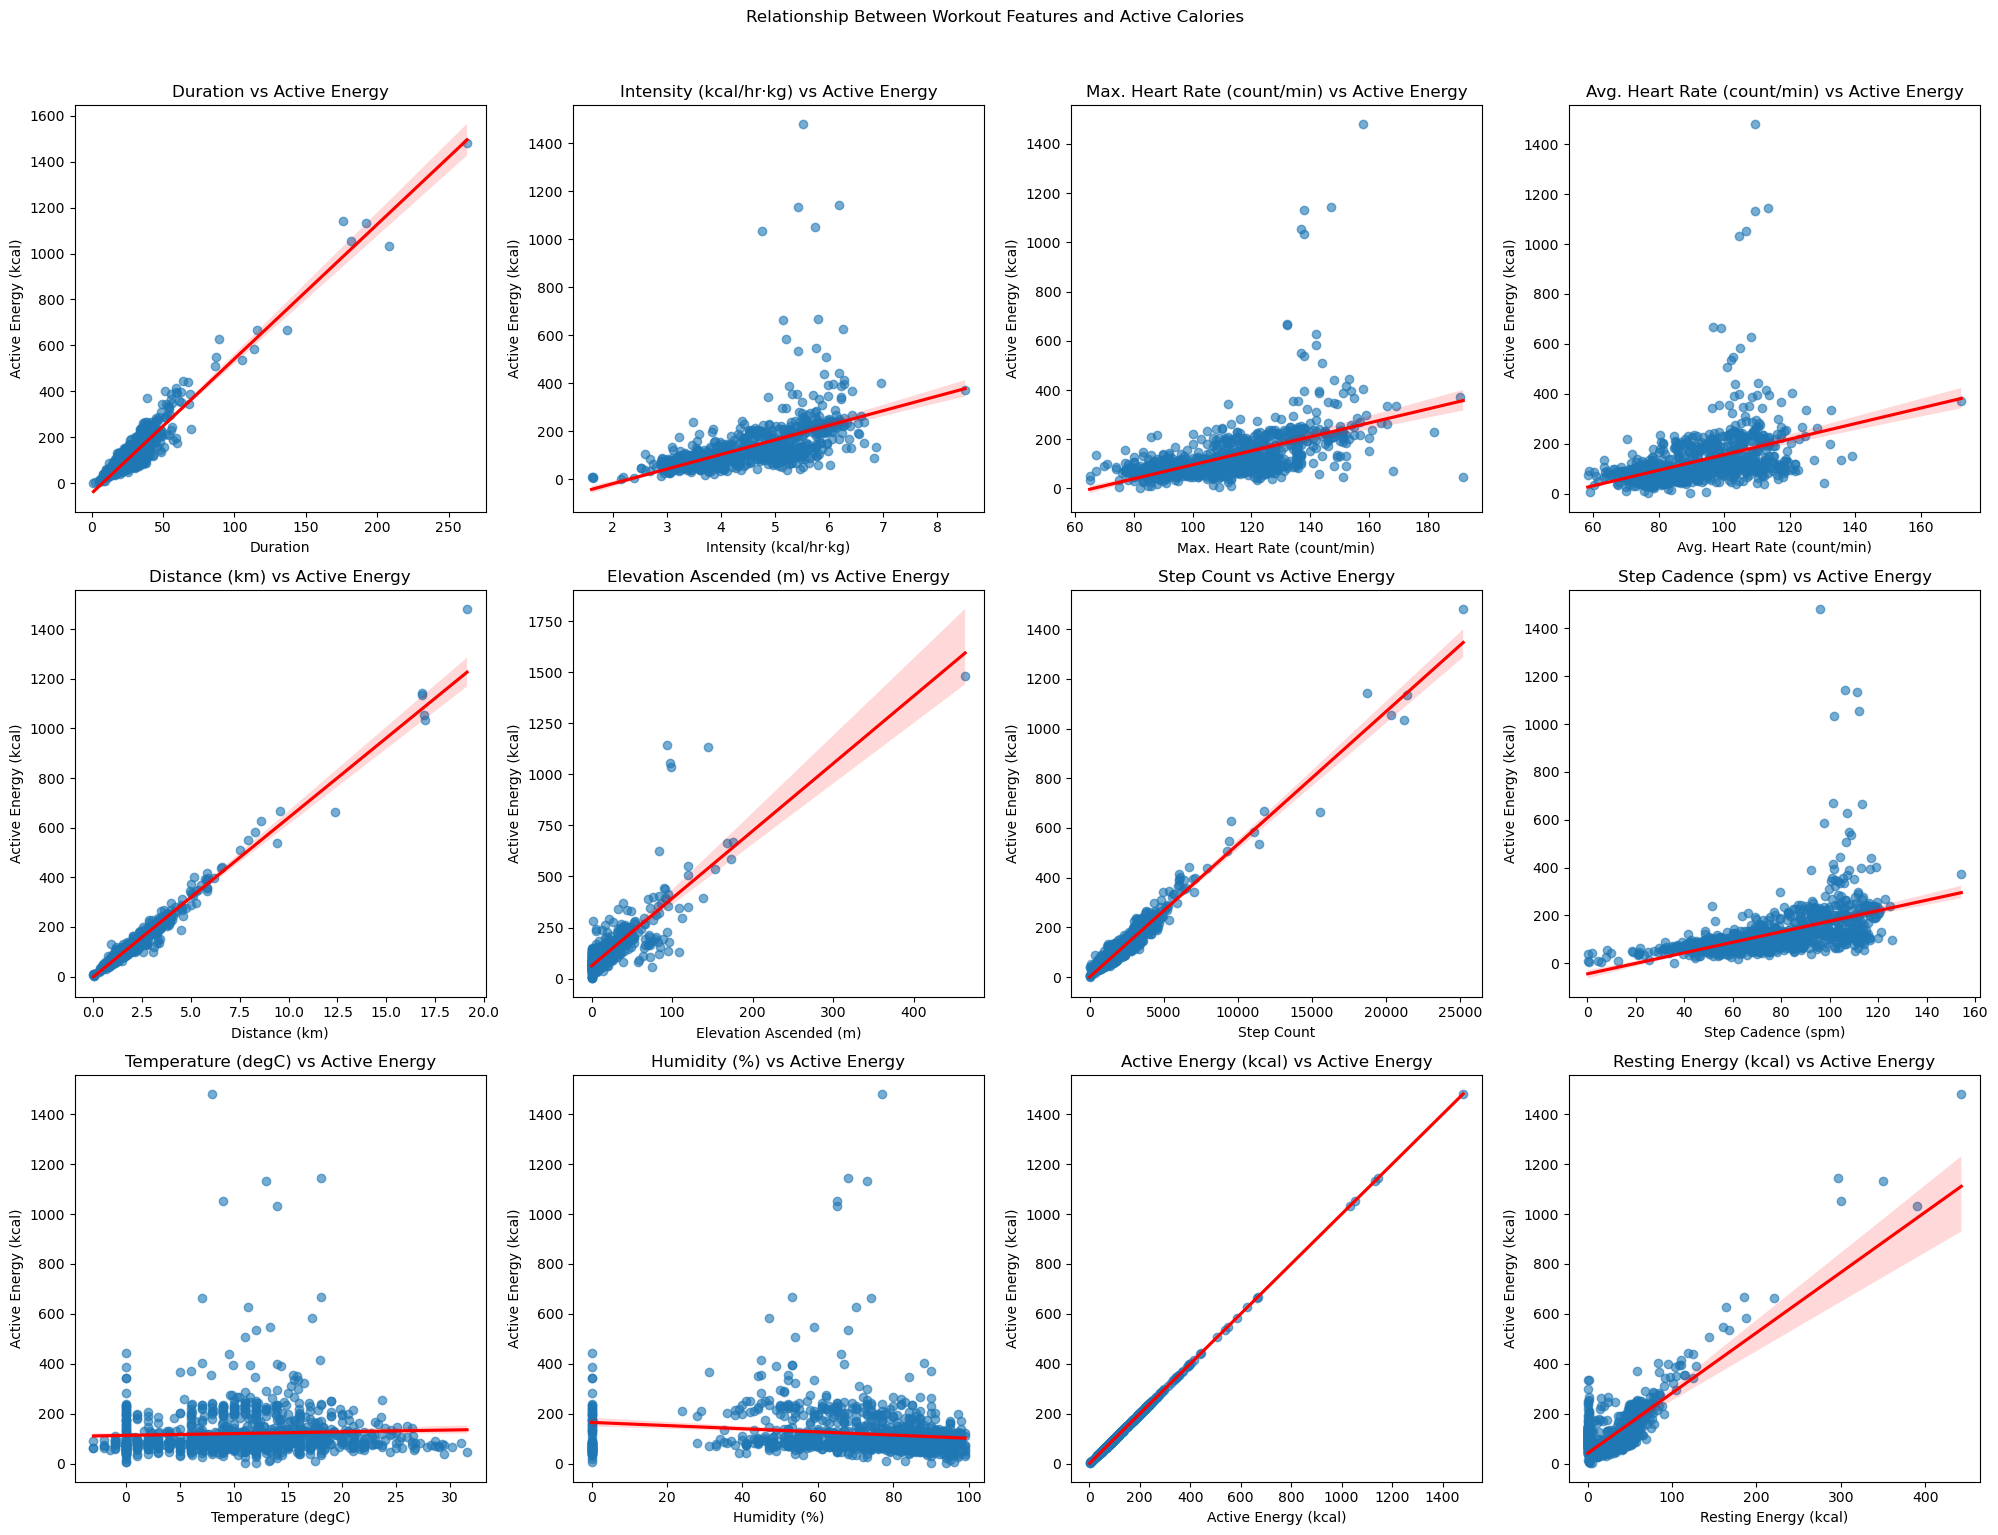

In [82]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.regplot(
        x=col,
        y='Active Energy (kcal)',
        data=df_walks,
        ax=axes[i],
        scatter_kws={'alpha': 0.6},
        line_kws={'color': 'red'}
    )
    axes[i].set_title(f'{col} vs Active Energy')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Relationship Between Workout Features and Active Calories', y=1.02)
plt.tight_layout()
plt.show()

## 9. Train/Test Split

The cleaned data was split into training and testing sets. The model learns from the training data, while the test data is held back to evaluate how well the model performs.

In [83]:
df_train, df_test = train_test_split(
    df_walks,
    test_size=0.2,
    random_state=44
)

print("Full dataset:", df_walks.shape)
print("Training set:", df_train.shape)
print("Testing set:", df_test.shape)

Full dataset: (1084, 14)
Training set: (867, 14)
Testing set: (217, 14)


## 10. Correlation and Feature Selection

A correlation heatmap was used to identify strong relationships between variables. This is especially important for linear regression because highly correlated predictor variables can cause multicollinearity.

For example, distance, duration, and step count are naturally related. Including all of them could make influence model.

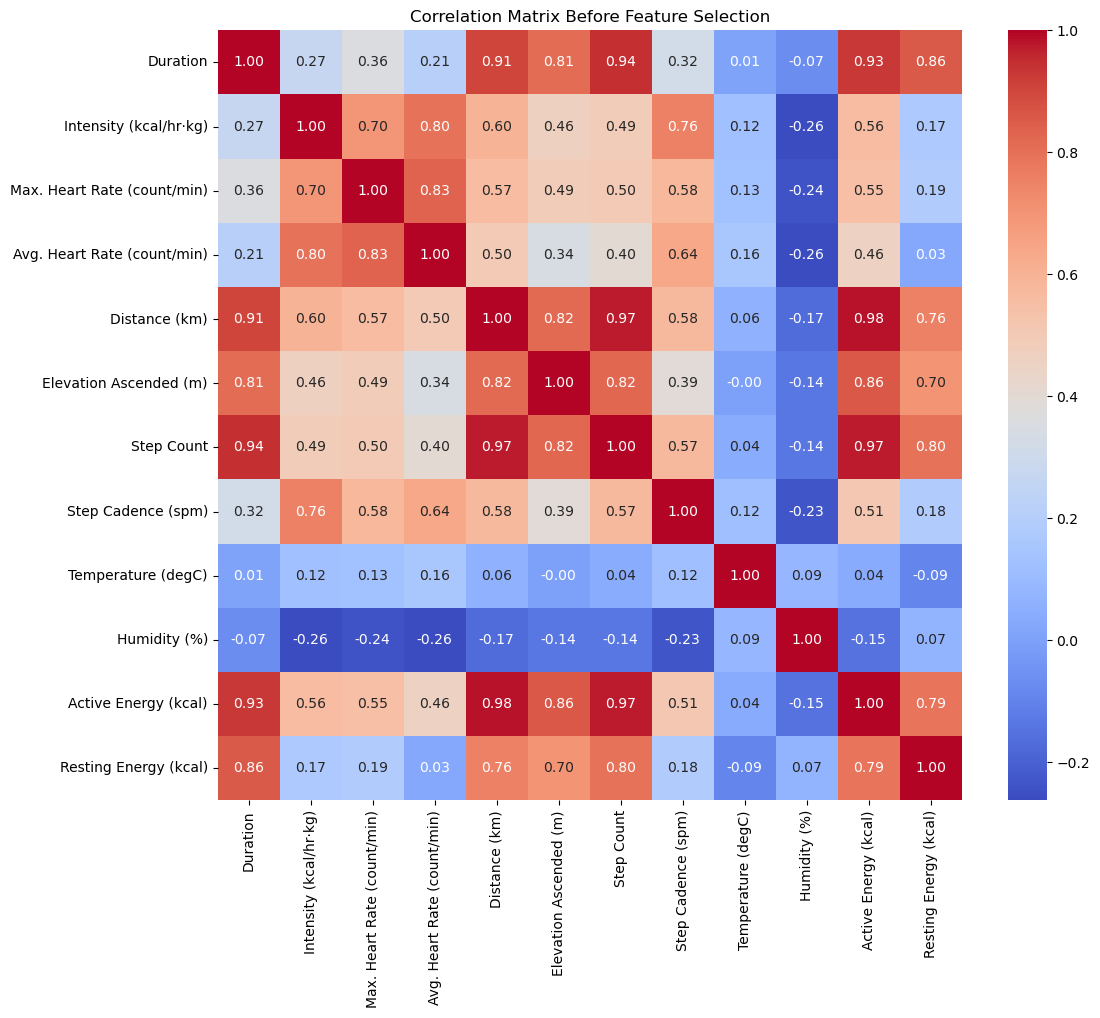

In [84]:
correlation_matrix = df_train.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Before Feature Selection')
plt.show()

In [85]:
columns_to_drop = [
    'Max. Heart Rate (count/min)',   # highly correlated with average heart rate
    'Duration',                      # highly correlated with distance
    'Step Count',                    # highly correlated with distance and cadence
    'Intensity (kcal/hr·kg)',        # depends on weight, which may not be accurate in the source data
    'Temperature (degC)',            # weak relationship with active calories
    'Humidity (%)',                  # weak relationship with active calories
    'Resting Energy (kcal)'          # not central to predicting active calories from the walk itself
]

# Drop the same columns from both train and test sets
df_train = df_train.drop(columns=columns_to_drop)
df_test = df_test.drop(columns=columns_to_drop)

print("Training columns after feature selection:")
print(df_train.columns.tolist())

Training columns after feature selection:
['Workout Type', 'Date', 'Avg. Heart Rate (count/min)', 'Distance (km)', 'Elevation Ascended (m)', 'Step Cadence (spm)', 'Active Energy (kcal)']


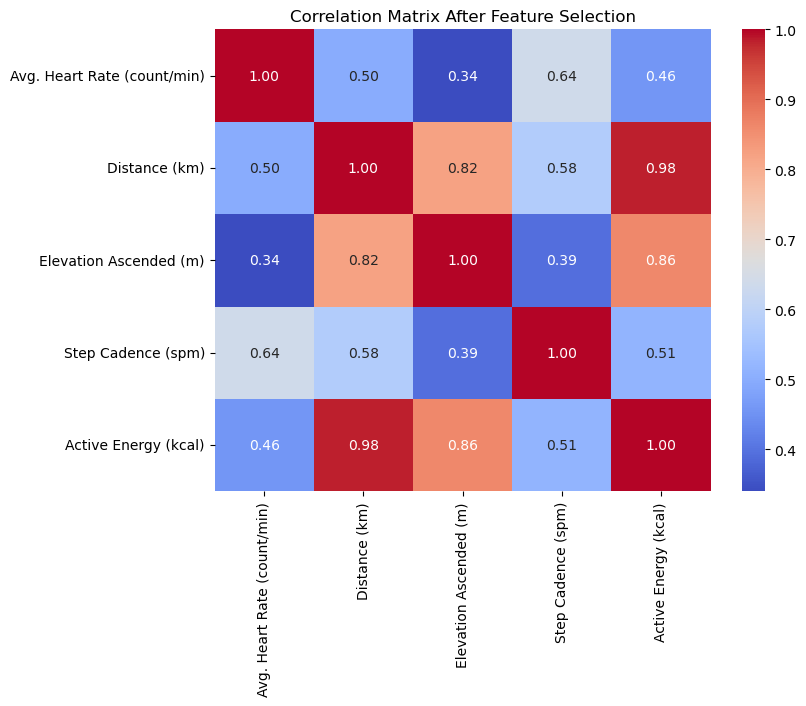

In [86]:
# Recheck the correlation matrix after feature selection
plt.figure(figsize=(8, 6))
sns.heatmap(df_train.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix After Feature Selection')
plt.show()

## 11. Build the Linear Regression Model

Linear regression was selected because the target variable showed strong linear relationships with several features, especially distance.

In [87]:
# Separate the target variable from the predictor variables
y_train = df_train['Active Energy (kcal)']
y_test = df_test['Active Energy (kcal)']

# Drop columns that should not be used 
X_train = df_train.drop(columns=['Active Energy (kcal)', 'Workout Type', 'Date'])
X_test = df_test.drop(columns=['Active Energy (kcal)', 'Workout Type', 'Date'])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (867, 4)
X_test shape: (217, 4)
y_train shape: (867,)
y_test shape: (217,)


In [88]:
# Train the linear regression model

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 12. Interpret the Model

The coefficients show how much the model expects active calories to change when each feature increases by one unit

In [89]:
# Display the model intercept and coefficients

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Intercept:", model.intercept_)
coef_df

Intercept: 20.562664741358546


,Feature,Coefficient
1,Distance (km),58.428891
2,Elevation Ascended (m),0.567898
0,Avg. Heart Rate (count/min),-0.027716
3,Step Cadence (spm),-0.238363


## 13. Evaluate Model Performance

Two metrics were used to evaluate the model:

- **R² score**: shows how much of the variation in active calories is explained by the model
- **Mean Absolute Error**: shows the average prediction error in calories

In [90]:
# Use the trained model to predict calories for the test set
y_pred = model.predict(X_test)

# Evaluate model performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.2f} calories")

R² Score: 0.982
Mean Absolute Error: 9.27 calories


## 14. Visualise Predictions

The chart below compares the model's predicted calorie values against the actual calorie values. 

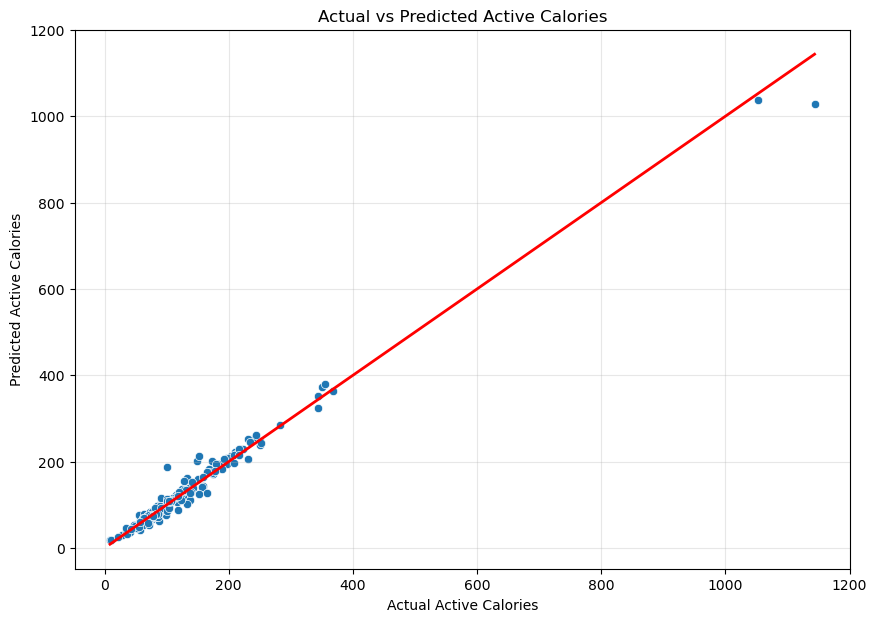

In [91]:
# Compare actual and predicted calorie values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred)

# Add a diagonal reference line for perfect predictions
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], color='red', linewidth=2)

plt.xlabel('Actual Active Calories')
plt.ylabel('Predicted Active Calories')
plt.title('Actual vs Predicted Active Calories')
plt.grid(True, alpha=0.3)
plt.show()

## 15. Conclusion

The model performed strongly on the test data, with an R² score of approximately **0.98** and an average error of around **10 calories per walk**.

The most influential predictor was **distance**. In this dataset, each additional kilometre walked was associated with 58 extra active calories burned. Elevation also had a positive effect, while average heart rate and step cadence had small negative coefficients.

These results partially support the original hypothesis.